<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.4
# *PCA Lab*

**In this lab, we will:**
- Explore how PCA is related to correlation.
- Use PCA to perform dimensionality reduction.

### 1. Load Data

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. n the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server: ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/

Also can be found on UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

Attribute Information:

1) ID number 2) Diagnosis (M = malignant, B = benign) 3-32)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter) b) texture (standard deviation of gray-scale values) c) perimeter d) area e) smoothness (local variation in radius lengths) f) compactness (perimeter^2 / area - 1.0) g) concavity (severity of concave portions of the contour) h) concave points (number of concave portions of the contour) i) symmetry j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

In [2]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

breast_cancer_csv = 'breast-cancer-wisconsin-data.csv'
df=pd.read_csv(breast_cancer_csv)

Saving breast-cancer-wisconsin-data.csv to breast-cancer-wisconsin-data (1).csv


### 2. EDA

Explore dataset. Clean data. Find correlation.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
# Check class distribution
df['diagnosis'].value_counts()
# Drop 'id' and unnamed column
df.drop(['id'], axis=1, inplace=True)
df.drop(['Unnamed: 32'], axis=1, inplace=True)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Convert M (malignant) and B (benign) into 1 and 0 for modeling.

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [9]:
# Correlation analysis

correlations = df.corr()['diagnosis'].sort_values(ascending=False)
print(correlations)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

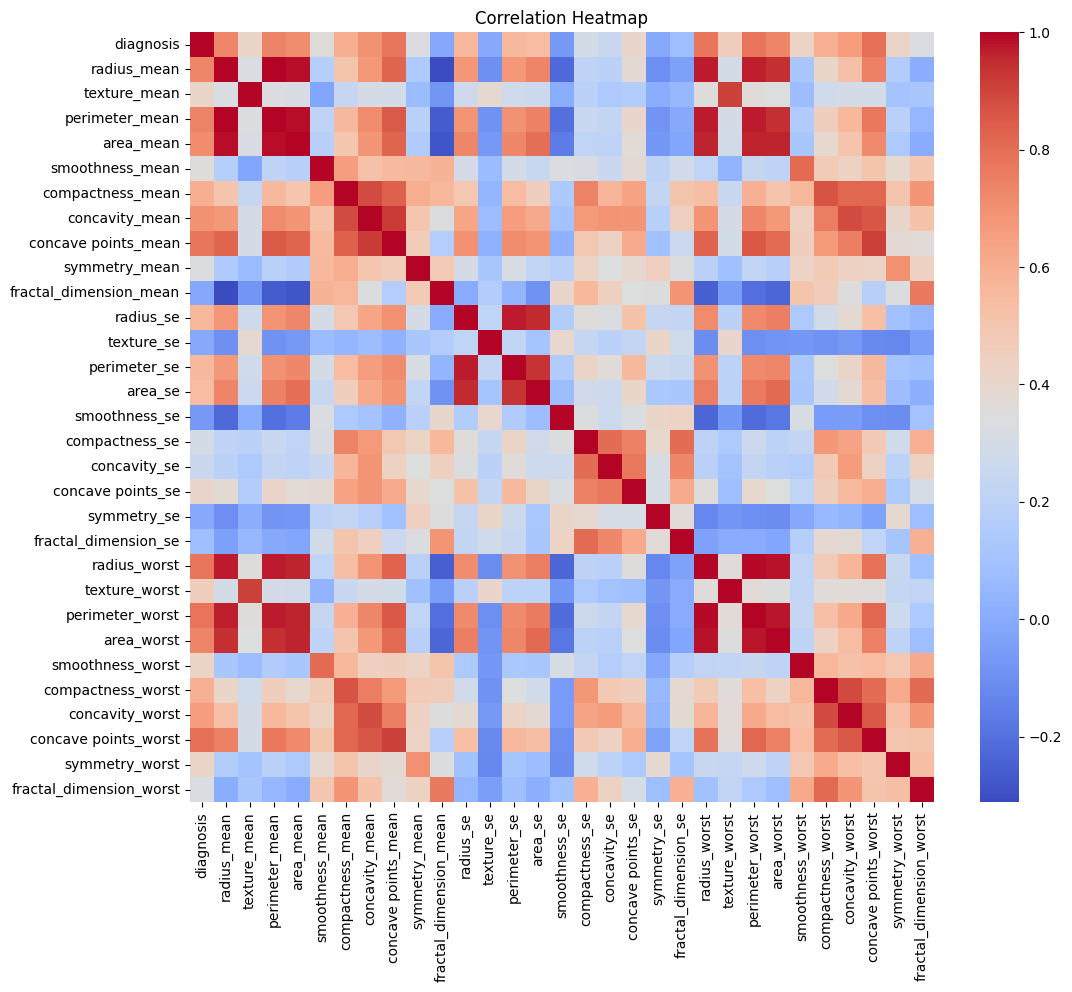

In [10]:
# Visualise with a heatmap

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 3. Subset & Normalise

Subset the data to only include all columns except diagnosis, then apply StandardScaler.

In [31]:
# ANSWER
from sklearn.preprocessing import StandardScaler

# Separate target variable
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0})
# Create the scaler and fit_transform the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Calculate correlation matrix

We will be using the correlation matrix to calculate the eigenvectors and eigenvalues.

In [15]:
# ANSWER
# If X_scaled is a NumPy array, convert it back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate correlation matrix
corr_matrix = X_scaled_df.corr()

# Display it
print(corr_matrix.round(2))

                         radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                     1.00          0.32            1.00       0.99   
texture_mean                    0.32          1.00            0.33       0.32   
perimeter_mean                  1.00          0.33            1.00       0.99   
area_mean                       0.99          0.32            0.99       1.00   
smoothness_mean                 0.17         -0.02            0.21       0.18   
compactness_mean                0.51          0.24            0.56       0.50   
concavity_mean                  0.68          0.30            0.72       0.69   
concave points_mean             0.82          0.29            0.85       0.82   
symmetry_mean                   0.15          0.07            0.18       0.15   
fractal_dimension_mean         -0.31         -0.08           -0.26      -0.28   
radius_se                       0.68          0.28            0.69       0.73   
texture_se                  

### 4. Calculate the eigenvalues and eigenvectors from the correlation matrix

numpy has a convenient function to calculate this:

    eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

In [16]:
# ANSWER
# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# Display the results
print("Eigenvalues:")
print(np.round(eigenvalues, 4))

print("\nEigenvectors (first 3 columns):")
print(np.round(eigenvectors[:, :3], 4))  # Show only first 3 for brevity


Eigenvalues:
[1.32816e+01 5.69140e+00 2.81790e+00 1.98060e+00 1.64870e+00 1.20740e+00
 6.75200e-01 4.76600e-01 4.16900e-01 3.50700e-01 2.93900e-01 2.61200e-01
 2.41400e-01 1.57000e-01 9.41000e-02 7.99000e-02 5.94000e-02 5.26000e-02
 4.95000e-02 1.00000e-04 7.00000e-04 1.60000e-03 6.90000e-03 8.20000e-03
 1.55000e-02 1.81000e-02 2.43000e-02 2.74000e-02 3.12000e-02 3.00000e-02]

Eigenvectors (first 3 columns):
[[ 0.2189 -0.2339 -0.0085]
 [ 0.1037 -0.0597  0.0645]
 [ 0.2275 -0.2152 -0.0093]
 [ 0.221  -0.2311  0.0287]
 [ 0.1426  0.1861 -0.1043]
 [ 0.2393  0.1519 -0.0741]
 [ 0.2584  0.0602  0.0027]
 [ 0.2609 -0.0348 -0.0256]
 [ 0.1382  0.1903 -0.0402]
 [ 0.0644  0.3666 -0.0226]
 [ 0.206  -0.1056  0.2685]
 [ 0.0174  0.09    0.3746]
 [ 0.2113 -0.0895  0.2666]
 [ 0.2029 -0.1523  0.216 ]
 [ 0.0145  0.2044  0.3088]
 [ 0.1704  0.2327  0.1548]
 [ 0.1536  0.1972  0.1765]
 [ 0.1834  0.1303  0.2247]
 [ 0.0425  0.1838  0.2886]
 [ 0.1026  0.2801  0.2115]
 [ 0.228  -0.2199 -0.0475]
 [ 0.1045 -0.0455 -0.

In [24]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

### 5. Calculate and plot the explained variance

A useful measure is the **explained variance**, which is calculated from the eigenvalues.

The explained variance tells us how much information (variance) is captured by each principal component.

### $$ ExpVar_i = \bigg(\frac{eigenvalue_i}{\sum_j^n{eigenvalue_j}}\bigg) * 100$$

In [21]:
def calculate_cum_var_exp(eig_vals):
    '''
    Calculate Explained Variance from Eigenvalues

    Return a list or array containing the cumulative explained variance
    '''
    total = np.sum(eig_vals)
    exp_var = [(i / total) * 100 for i in eig_vals]
    cum_var_exp = np.cumsum(exp_var)
    return cum_var_exp

In [26]:
def plot_var_exp(eig_vals):

    cum_var_exp = calculate_cum_var_exp(eig_vals)

    plt.figure(figsize=(9,7))

    component_number = [i+1 for i in range(len(cum_var_exp))]

    plt.plot(component_number, cum_var_exp, lw=7)

    plt.axhline(y=0, linewidth=5, color='grey', ls='dashed')
    plt.axhline(y=100, linewidth=3, color='grey', ls='dashed')

    ax = plt.gca()
    ax.set_xlim([1,30])
    ax.set_ylim([-5,105])

    ax.set_ylabel('cumulative variance explained', fontsize=16)
    ax.set_xlabel('component', fontsize=16)

    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(12)

    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(12)

    ax.set_title('component vs cumulative variance explained\n', fontsize=20)

    plt.show()

### 6. Using sklearn For PCA

    from sklearn.decomposition import PCA
    
- Create an instance of PCA
    - Fit X
- Plot the cumulative explained variance
- Apply dimensionality reduction to X with n_components=16
    - Fit and transform X
- Create a pairplot of PCA-transformed data

In [ ]:
# ANSWER
# Create an instance of PCA (do not set n_components)
from sklearn.decomposition import PCA

# Create a PCA instance
pca = PCA()

# Fit Xs (breast cancer dataset having standardised features)
pca.fit(X_scaled)



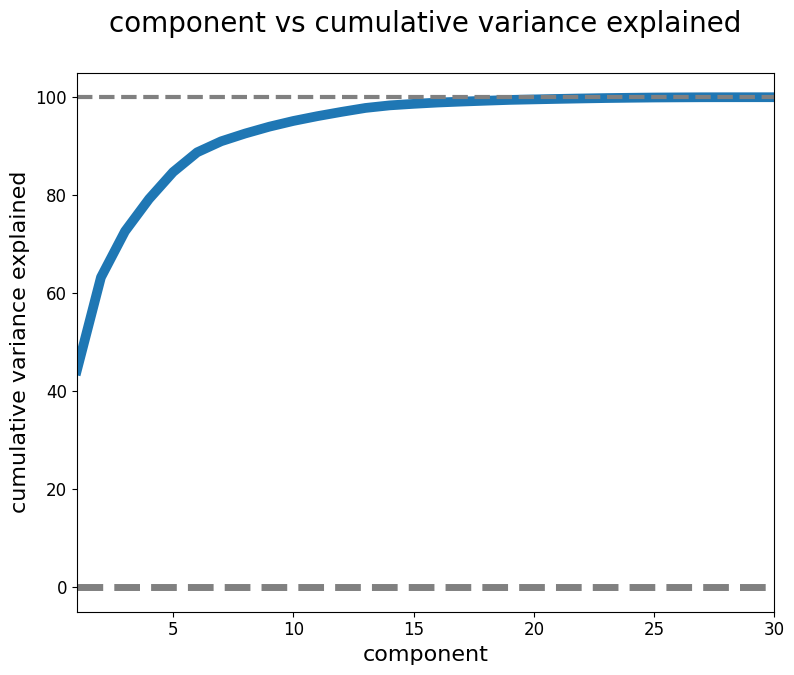

In [28]:
# ANSWER
# Plot cumulative variance explained vs number of components using the plot_var_exp function from above
plot_var_exp(eigenvalues_sorted)

In [35]:
# ANSWER
# Create another instance of PCA (this time with n_components = 16)
from sklearn.decomposition import PCA

# Create a PCA instance keeping 16 components
pca_16 = PCA(n_components=16)

# Fit and transform Xs (breast cancer dataset having standardised features)
X_pca_16 = pca_16.fit_transform(X_scaled)

# Check shape to confirm reduction
print("Original shape:", X_scaled.shape)
print("Transformed shape:", X_pca_16.shape)

Original shape: (569, 30)
Transformed shape: (569, 16)


In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (
df = pd.read_csv('breast-cancer-wisconsin-data.csv')

# Drop ID and unnamed columns
df.drop(['id'], axis=1, inplace=True)
if 'Unnamed: 32' in df.columns:
    df.drop(['Unnamed: 32'], axis=1, inplace=True)

# Create y (target) and X (predictors)
y = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(['diagnosis'], axis=1)

# Standardize X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 16 components
pca = PCA(n_components=16)
X_pca_16 = pca.fit_transform(X_scaled)



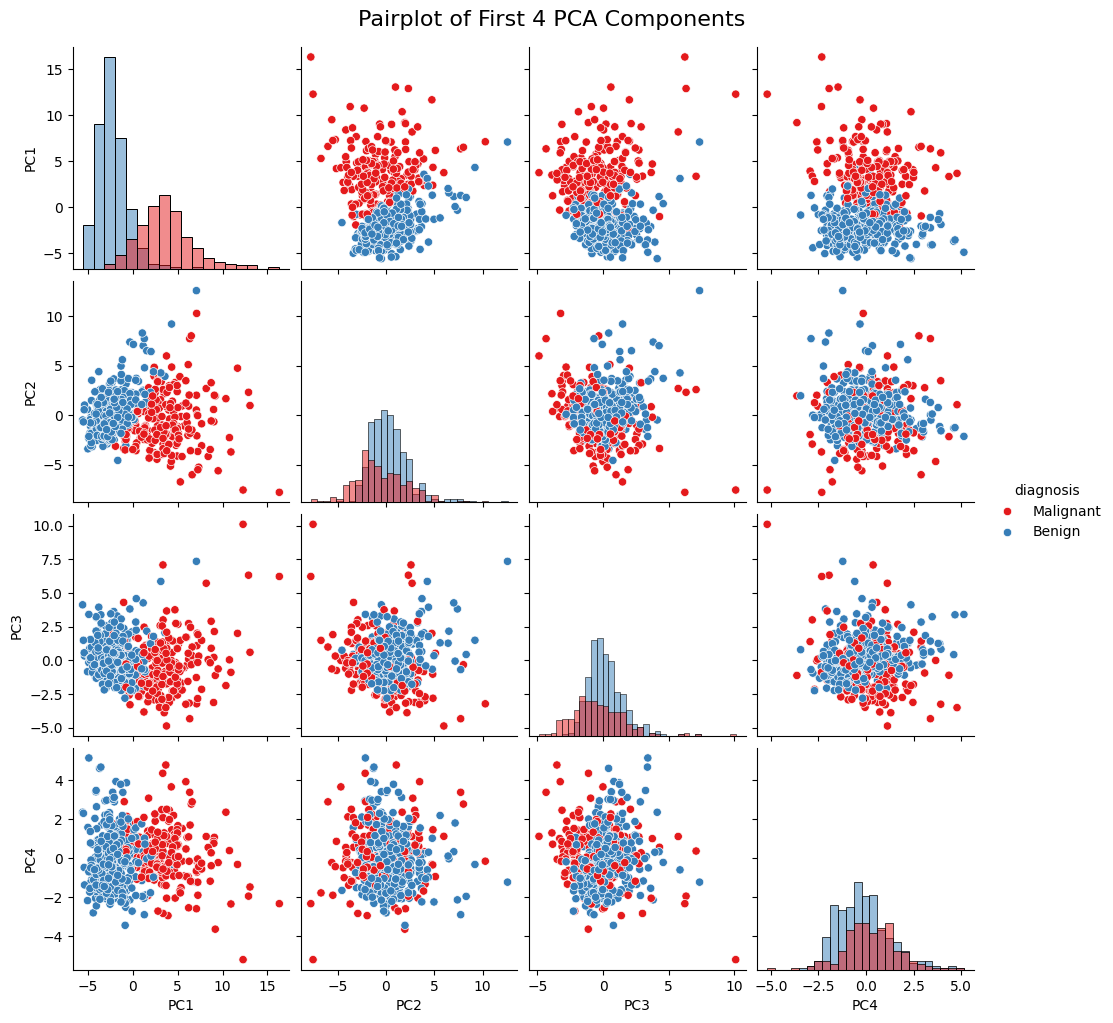

In [37]:
# ANSWER
# Create a pairplot of PCA-transformed data
# Convert the PCA-transformed data (first 4 components) into a DataFrame
pca_df = pd.DataFrame(X_pca_16[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])

# Add the target variable for color
pca_df['diagnosis'] = y.map({0: 'Benign', 1: 'Malignant'})

# Plot pairplot
sns.pairplot(pca_df, hue='diagnosis', palette='Set1', diag_kind='hist')
plt.suptitle('Pairplot of First 4 PCA Components', y=1.02, fontsize=16)
plt.show()

You should notice that the transformed features have been decorrelated (neither increasing nor decreasing trends in pairs of variables).

### 7. Split Data to 80/20 and use PCA prior to a supervised learning task

In this section we use PCA as a preprocessing step to a supervised learning algorithm.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

Split the original dataset 80/20. Then apply standard scaler followed by PCA.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply standard scaler to X_train and X_test (fit_transform on X_train, transform on X_test):
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the PCA class and set at 16 components
pca = PCA(n_components=16)

# Apply PCA to the standardised features
X_train_scaled_pca = pca.fit_transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

Apply a KNN algorithm on `X_train_scaled` and `X_train_scaled_pca` with 5 neighbours, then evaluate using `X_test_scaled` and `X_test_scaled_pca`. Has performance been impacted as a result of dimension reduction?

In [43]:
# Set KNN classifier to use 5 neighbours and fit to X_train_scaled
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_standard = KNeighborsClassifier(n_neighbors=5)
knn_standard.fit(X_train_scaled, y_train)
y_pred_standard = knn_standard.predict(X_test_scaled)
# Test accuracy of KNN using standardised data
accuracy_standard = accuracy_score(y_test, y_pred_standard)
print(f"KNN Accuracy WITHOUT PCA: {accuracy_standard:.2%}")

KNN Accuracy WITHOUT PCA: 95.61%


In [44]:
# Set KNN classifier to use 5 neighbours and fit to X_train_scaled_pca
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_scaled_pca, y_train)
# Predict on PCA-transformed test set
y_pred_pca = knn_pca.predict(X_test_scaled_pca)

# Test accuracy of KNN using standardised PCA-transformed data
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"KNN Accuracy WITH PCA (16 components): {accuracy_pca:.2%}")

KNN Accuracy WITH PCA (16 components): 95.61%


**References**

[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data/downloads/breast-cancer-wisconsin-data.zip/2)

[Breast Cancer Machine Learning Prediction](https://gtraskas.github.io/post/breast_cancer/)

[Understanding PCA (Principal Component Analysis) with Python](https://towardsdatascience.com/dive-into-pca-principal-component-analysis-with-python-43ded13ead21)



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



